In [1]:
!pip install ipywidgets
!pip install pygraphviz
!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.8 MB/s eta 0:00:00
Selecting previously unselected package libatk1.0-data.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ..

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- keras library --
try:
    import tensorflow as tf
except:
    !uv pip install tensorflow
    import tensorflow as tf

from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras.utils import plot_model
# os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from tqdm import tqdm
from time import time, sleep

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay, RocCurveDisplay

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, MissingIndicator, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [7]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


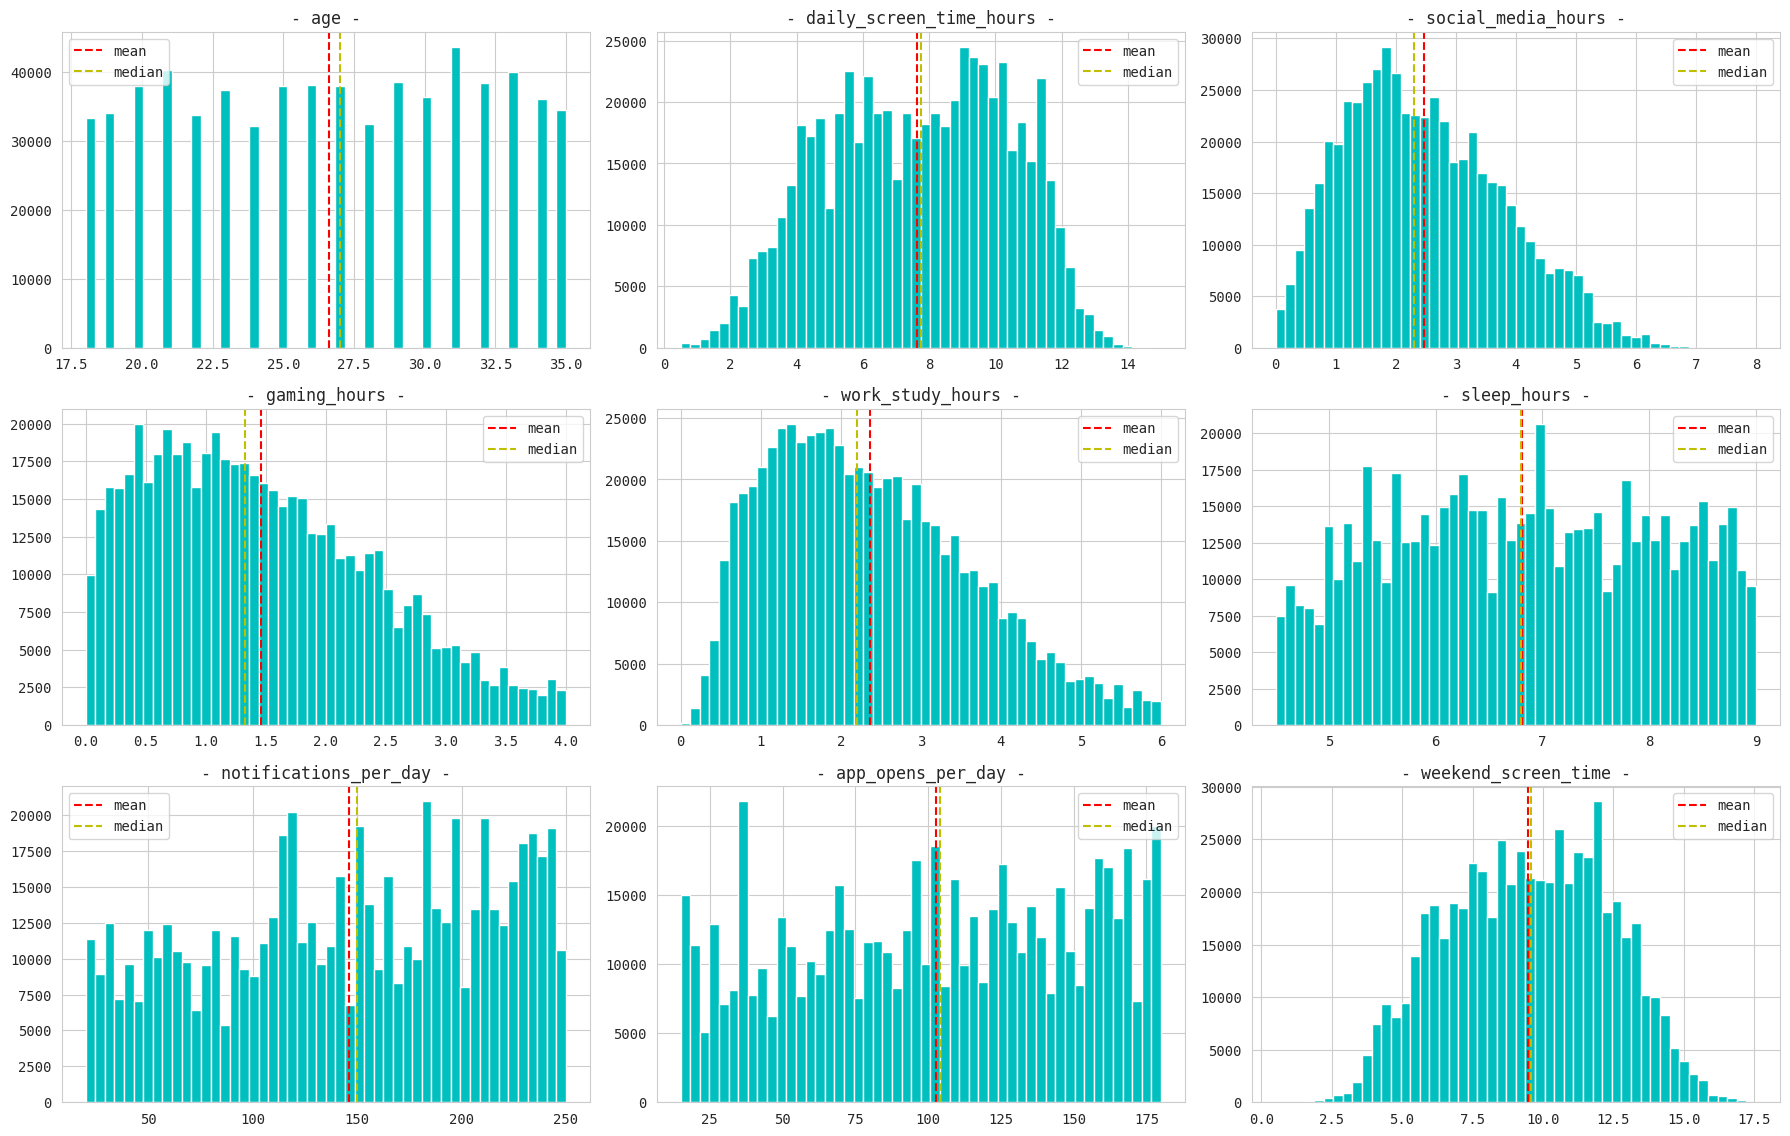

In [9]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f"- {col} -")
    plt.legend()

plt.tight_layout()
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [11]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [12]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end="")
# for col in NUMS:
#     freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
#     n = f"{col}_FREQ"
#     print(n+", ", end="")
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype("float32")
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

# train[NUMS+FREQ_COLS]

In [19]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [20]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    # num_to_cat = []
    # for col in num_features_:
    #     cat_name = f"{col}_cat"
    #     df[cat_name] = df[col].fillna('NaN').astype(str)
    #     num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = ["missing_count"]
new_cats.extend([
    c for c in FE_COLS
    if "_round" in c
    or c.endswith("_cat")
    or c.startswith("ci_")
])

new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
NUMS.extend(FE_COLS)

display(train[new_cats+new_nums].head())

train[FE_COLS].dtypes

,missing_count,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour
0,1,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,1.0,1.0,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,NaN,1.86,0.93,1.86,NaN,2.0,1.0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297
2,3,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,NaN,NaN,NaN,NaN,NaN,0.0,3.0,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078
3,1,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,NaN,NaN,NaN,NaN,0.38,0.0,0.0,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456
4,2,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,NaN,NaN,NaN,NaN,4.57,0.0,0.0,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN


age_round0                        float64
age_round1                        float64
daily_screen_time_hours_round0    float64
daily_screen_time_hours_round1    float64
social_media_hours_round0         float64
social_media_hours_round1         float64
gaming_hours_round0               float64
gaming_hours_round1               float64
work_study_hours_round0           float64
work_study_hours_round1           float64
sleep_hours_round0                float64
sleep_hours_round1                float64
notifications_per_day_round0      float64
notifications_per_day_round1      float64
app_opens_per_day_round0          float64
app_opens_per_day_round1          float64
weekend_screen_time_round0        float64
weekend_screen_time_round1        float64
total_breakdown_hours             float64
social_ratio                      float64
gaming_ratio                      float64
work_ratio                        float64
unaccounted_screen_time           float64
screen_to_sleep_ratio             

In [21]:
train[FE_COLS].nunique().sort_values()

ci_case                                3
gaming_hours_round0                    5
ci_n_missing                           5
sleep_hours_round0                     6
work_study_hours_round0                7
social_media_hours_round0              9
missing_count                         12
daily_screen_time_hours_round0        16
age_round1                            18
age_round0                            18
weekend_screen_time_round0            18
gaming_hours_round1                   41
sleep_hours_round1                    46
work_study_hours_round1               61
social_media_hours_round1             81
daily_screen_time_hours_round1       146
app_opens_per_day_round0             166
app_opens_per_day_round1             166
weekend_screen_time_round1           167
notifications_per_day_round0         231
notifications_per_day_round1         231
ci_daily_lb                         2222
total_breakdown_hours               3063
ci_missing_comp_ub                  4211
ci_interval_widt

In [22]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"TE_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [25]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [26]:
# ## -- Apply log transformation --
# for df in [train, test, orig]:
#     df['log_RaceProgress'] = np.log(df['RaceProgress'])
#     df['log_LapTime_s'] = np.log(df['LapTime (s)'])

# log_features = ['log_RaceProgress', 'log_LapTime_s']

# ## -- Absolute values --
# for df in [train, test, orig]:
#     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
#     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# abs_features = ['abs_lap_delta', 'abs_degrade']

# plt.figure(figsize=(18, 8))
# for i, col in enumerate(log_features+abs_features):
#     plt.subplot(2, 2, i+1)
#     plt.hist(train[col], bins=50)
#     # orig[col].plot.hist()
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [27]:
# ## -- Lag/Differential features --
# # ['Delta_lag1', 'Delta_roll3_mean', 'Deg_diff', 'TyreLife_growth', 'LapTime_lag1', 'LapTime_diff']

# for df in [train, test, orig]:
#     df['Degrade_diff'] = df['Cumulative_Degradation'].diff()
#     df['LapTime_diff'] = df['LapTime (s)'].diff()
#     df['Delta_roll_3'] = df['LapTime_Delta'].rolling(3).mean()
#     # df['Delta_roll_3_LapNum'] = df['LapTime_Delta'].rolling(3).mean()
#     df['LapTime_delta_shift'] = df['LapTime (s)'].shift(3) #'infer, 'D'

# lag_features = [
#     'Degrade_diff',
#     'LapTime_diff',
#     'Delta_roll_3',
#     # 'Delta_roll_3_LapNum',
#     'LapTime_delta_shift'
# ]

# train[lag_features].describe()
# # train.head()

In [28]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

combined = pd.concat([train, test, orig])

combined[CATS] = combined[CATS].fillna("_EMPTY_").astype(str)
## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS):
#     n = f"cat_{c}"
#     combined[n] = combined[c].factorize()[0]
#     CATS_2.append(n)
# # CATS.extend(CATS_2)
# FEATURES.extend(CATS_2)
## ------------------------------------------------------------
# ## -- Factorize all CATS data --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")
print("Total Features:", len(FEATURES))

train

Label encoding complete!
Total Features: 47


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_EMPTY_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_EMPTY_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0.0,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,5.0,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,_EMPTY_,_EMPTY_,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,0.0,0.0,2.0,1.0


In [29]:
# ## -- Get missing_indicators --

# indicator = MissingIndicator()

# tr = pd.DataFrame(indicator.fit_transform(train[NUMS])).astype('int8')
# tr.columns = ["indicator_" + str(c) for c in tr.columns]
# train = pd.concat([train, tr], axis=1)

# ts = pd.DataFrame(indicator.transform(test[NUMS])).astype('int8')
# ts.columns = ["indicator_" + str(c) for c in ts.columns]
# test = pd.concat([test, ts], axis=1)

# og = pd.DataFrame(indicator.transform(orig[NUMS])).astype('int8')
# og.columns = ["indicator_" + str(c) for c in og.columns]
# orig = pd.concat([orig, og], axis=1)

# indicators = tr.columns.tolist()
# CATS.extend(indicators)
# print(CATS)

# train

In [30]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

train

Total Features: 47


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_EMPTY_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_EMPTY_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0.0,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,5.0,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,_EMPTY_,_EMPTY_,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,0.0,0.0,2.0,1.0


# ML TRAINING

In [31]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace = None,
#     layer_units: list = [128, 64, 32],
#     learning_rate: float = 0.01,
#     drop_rate: float = 0.1,
#     activation: str = "relu",
#     l2_reg = tf.keras.regularizers.L2(0.0)
# ):
#     # 1. Retrieve structural components from the globally adapted FeatureSpace
#     dict_inputs = feature_space.get_inputs()
#     encoded_features = feature_space.get_encoded_features()

#     print(f"Dict_input shape: {len(dict_inputs)}", end=" | ")
#     print(f"FS_encoded shape: {encoded_features.shape} +++ Loop model +++")
#     print('-'*90)

#     # 2. Build the Core Deep Neural Network using the Functional API safely
#     # This ensures layers are completely reusable across train/inference topologies
#     x = encoded_features

#     # Clean, dynamic looping over layer configuration list
#     for units in layer_units:
#         x = tf.keras.layers.Dense(
#             units,
#             activation=activation,
#             kernel_regularizer=l2_reg)(x)
#         x = tf.keras.layers.BatchNormalization()(x)
#         x = tf.keras.layers.Dropout(drop_rate)(x)

#     # Final Binary Classification Output Node
#     final_output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

#     train_model = tf.keras.Model(inputs=encoded_features, outputs=final_output)
#     infer_model = tf.keras.Model(inputs=dict_inputs, outputs=final_output)

#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, weight_decay=0.0),
#         loss="binary_crossentropy",
#         metrics=[tf.keras.metrics.AUC(name="auc")]
#     )

#     return train_model, infer_model

# print("⚙️ Optimized Keras model builder ready ⚙️")

In [32]:
def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace = None,
    layer_units: list = [128, 64, 32],
    learning_rate: float = 0.01,
    drop_rate: float = 0.1,
    activation: str = "relu",
    l2_reg = tf.keras.regularizers.L2(0.0),
):

    # 1. Setup Inputs
    dict_inputs = feature_space.get_inputs()
    encoded_features = feature_space.get_encoded_features()

    print(f"Dict_Input: {len(dict_inputs)}", end=" | ")
    print(f"FS_Encoded: {encoded_features.shape} +++ Sequential model +++")
    print('-'*90)

    # 2. Create the Sequential model
    outputs = tf.keras.Sequential([
        # keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(layer_units[0], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(layer_units[1], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(layer_units[2], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- Output --
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])(encoded_features)

    # Connect everything
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)
    train_model.compile(
        # optimizer=keras.optimizers.Adam(learning_rate, weight_decay=None), # 0.02
        # optimizer=tf.keras.optimizers.RMSprop(learning_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate, weight_decay=0.0),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
        )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

    return train_model, infer_model

print("⚙️ Keras model ready ⚙️")

⚙️ Keras model ready ⚙️


In [33]:
# %%writefile main_trainer.py

# ## -- Define CV Trainer --
# class TrainerCV:
#     def __init__(
#         self,
#         model_builder,
#         model_name: str,
#         train_df: pd.DataFrame,
#         test_df: pd.DataFrame,
#         features: list, # This `features` should be the base features, not meant to be modified
#         target: str,
#         kfold,
#         batch_size: int=32,
#         epochs: int=10,
#         drop_rate: float=0.1,
#         patience: int=3,
#         layer_units: list=[128, 64, 32],
#         learning_rate: float=0.01,
#         activation: str="relu",
#         eval_metric: str="auc",
#         use_original: bool=False,
#         **kwargs
#     ):
#         self.model_builder = model_builder
#         self.model_name = model_name
#         self.train_df = train_df
#         self.test_df = test_df
#         self.features = features # Store the initial base features
#         self.target = target
#         self.kfold = kfold
#         self.batch_size = batch_size
#         self.epochs = epochs
#         self.drop_rate = drop_rate
#         self.patience = patience
#         self.layer_units = layer_units
#         self.learning_rate = learning_rate
#         self.activation = activation
#         self.eval_metric = eval_metric
#         self.use_original = use_original

#         self.result = None

#         # Storage
#         self.oof_preds   = np.zeros(len(train_df))
#         self.test_preds  = np.zeros(len(test_df))
#         self.fold_scores = []

#     def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
#         # This helper can be extended if you want to apply masks or augmentation.
#         return X, y

#     def _feature_space_transform(self, train_data: pd.DataFrame, batch_input, features_for_adaptation: list):
#         """Initializes and adapts Keras FeatureSpace globally once."""

#         feature_specs = {}

#         for col in features_for_adaptation:
#             if col in CATS: # Check if it's a known categorical feature
#                 feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)
#             elif col in NUMS: # Check if it's a known numerical feature
#                 feature_specs[col] = FeatureSpace.float_normalized()
#                 # if col == "0000":
#                 #     feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)
#                 #     # feature_specs[col] = FeatureSpace.float_discretized(num_bins=6)
#                 # elif self.train_df[col].nunique() < 1000:
#                 #     feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
#                 # else:
#                 #     feature_specs[col] = FeatureSpace.float_discretized(num_bins=64)
#             # elif col.startswith("oTE_") and col.endswith(("_mean", "_median")):
#             #     feature_specs[col] = FeatureSpace.float()
#             # elif col.startswith("TE_") and col.endswith(("_mean", "_median")):
#             #     feature_specs[col] = FeatureSpace.float()
#             # elif col.startswith(("oTE_", "TE_")) and col.endswith("_count"):
#             #     feature_specs[col] = FeatureSpace.float_normalized()
#             # elif col.startswith("indicator_"): # Added for missing indicators
#             #     feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=0)
#             # elif col in FE_COLS:
#             #     feature_specs[col] = FeatureSpace.float_normalized()
#             else:
#                 # Default for any other unexpected numeric features
#                 feature_specs[col] = FeatureSpace.float()

#         ## -- Cross features (if any are explicitly defined) --
#         feature_crosses = [
#             # FeatureSpace.cross(('age', 'gender'), crossing_dim=8), # 18*3=20
#             # FeatureSpace.cross(('Year', 'Stint'), crossing_dim=4), # 4*8=32
#             # FeatureSpace.cross(('Year', 'Race'), crossing_dim=12), # 4*25=100
#             # FeatureSpace.cross(('Year', 'PitStop'), crossing_dim=4), # 4*2=8
#             # FeatureSpace.cross(('Year', 'TyreLife'), crossing_dim=8), # 4*10=40
#         ]

#         # for c1, c2 in itertools.combinations(CATS, 2):
#         #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=8))

#         _fs = FeatureSpace(
#             features=feature_specs,
#             crosses=feature_crosses,
#             output_mode="concat",
#             name="feature_processed",
#         )

#         ds = tf.data.Dataset.from_tensor_slices(
#             (dict(train_data[features_for_adaptation]), train_data[self.target])
#         ).batch(batch_input)

#         no_labels = ds.map(lambda x, _: x)
        
#         print(f"♨︎ FeatureSpace.adapt() to {len(features_for_adaptation)} features... ", end="")
#         _fs.adapt(no_labels)
        
#         print(f"☑️ Complete!\n")

#         return _fs


#     def fit(self):
#         print(f"\n===== Starting CV: {self.model_name} | {get_system_info()} =====")
#         t0 = time()

#         # Clear Keras session to reset models and graphs and free memory
#         tf.keras.backend.clear_session()

#         self.oof_preds   = np.zeros(len(self.train_df))
#         self.test_preds  = np.zeros(len(self.test_df))
#         self.oof_scores  = []
#         self.fold_histories = []

#         # Create a local list of features for the current run, based on self.features
#         feature_cols_for_model = list(self.features)

#         if self.use_original:
#             # Assuming 'orig' DataFrame is accessible in this scope (it is, from global)
#             orig_aggs = ["mean"]

#             # Apply orig_TE_data_propagate to a copy of train_df to avoid modifying it
#             X_tr, orig_cols = orig_TE_data_propagate(
#                 orig, # global 'orig' df
#                 self.train_df,
#                 target=self.target,
#                 features=BASE, # Use BASE here, as these are the original features for TE
#                 aggs=orig_aggs,
#                 fill_nan=True,
#             )

#             # Apply orig_TE_data_propagate to a copy of test_df
#             x_test, _ = orig_TE_data_propagate(
#                 orig, # global 'orig' df
#                 self.test_df,
#                 target=self.target,
#                 features=BASE, # Use BASE here
#                 aggs=orig_aggs,
#                 fill_nan=True,
#             )
#             feature_cols_for_model.extend(orig_cols) # Extend the local copy

#             X    = X_tr[feature_cols_for_model].copy()
#             X_ts = x_test[feature_cols_for_model].copy()
#             y    = X_tr[self.target]
#         else:
#             X    = self.train_df[feature_cols_for_model].copy()
#             X_ts = self.test_df[feature_cols_for_model].copy()
#             y    = self.train_df[self.target]

#         # # ---- Global categorical imputation outside fold ----
#         # # Ensure that only the CATS columns present in X and X_ts are processed
#         # current_cats_in_X = [col for col in CATS if col in X.columns]
#         # current_cats_in_X_ts = [col for col in CATS if col in X_ts.columns]

#         # for col in current_cats_in_X:
#         #     X[col] = X[col].fillna("EMPTY").astype(str)
#         # for col in current_cats_in_X_ts:
#         #     X_ts[col] = X_ts[col].fillna("EMPTY").astype(str)

#         strategy = tf.distribute.MirroredStrategy()
#         GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
#         print(f"⚙️ Number of devices: {strategy.num_replicas_in_sync}")

#         ## -- Apply FeatureSpace (Impute NaN first) --
#         train_adapt_df = pd.concat([X, y], axis=1)

#         fs_imputer = SimpleImputer(strategy="mean")
#         # Ensure that only the NUMS columns present in train_adapt_df are imputed
#         nums_to_impute = [col for col in NUMS if col in train_adapt_df.columns] #+FE_COLS
#         if nums_to_impute:
#             train_adapt_df.loc[:, nums_to_impute] = fs_imputer.fit_transform(train_adapt_df[nums_to_impute])

#         feature_space_module = self._feature_space_transform(
#             train_adapt_df,
#             GLOBAL_BATCH_SIZE,
#             features_for_adaptation=feature_cols_for_model, # Pass the current set of features
#         )

#         for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
#             print(f"\n===== Fold {idx}/{self.kfold.n_splits}", end=" | ")

#             X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
#             y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
#             X_test = X_ts.copy()

#             # ---- Numerical Imputation for current fold ----
#             num_imputer_fold = SimpleImputer(strategy="mean")
#             nums_to_impute_fold = [col for col in NUMS if col in X_train.columns] #+FE_COLS
#             if nums_to_impute_fold:
#                 X_train.loc[:, nums_to_impute_fold] = num_imputer_fold.fit_transform(X_train[nums_to_impute_fold])
#                 X_valid.loc[:, nums_to_impute_fold] = num_imputer_fold.transform(X_valid[nums_to_impute_fold])
#                 X_test.loc[:, nums_to_impute_fold]  = num_imputer_fold.transform(X_test[nums_to_impute_fold])

#             ## -- Create tf.data.Datasets for training and validation --
#             X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_train_ds = (X_train_ds.map(
#                 lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().shuffle(buffer_size=len(X_train)).prefetch(tf.data.AUTOTUNE))

#             X_val_ds = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_val_ds = (X_val_ds.map(
#                 lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().prefetch(tf.data.AUTOTUNE))

#             X_test_ds = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_test_ds = (X_test_ds.map(
#                 lambda x: feature_space_module(x), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().prefetch(tf.data.AUTOTUNE))

#             # Distribute datasets natively for the Mirrored Strategy scope 🔥
#             dist_train_ds = strategy.experimental_distribute_dataset(preprocessed_train_ds)
#             dist_val_ds = strategy.experimental_distribute_dataset(preprocessed_val_ds)

#             if idx == 1:
#                 print(f"shape: {X_train.shape}")
#                 display(X_train.head())

#             ## -- Define callbacks --
#             callbacks = [
#                 tf.keras.callbacks.EarlyStopping(
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     patience=self.patience,
#                     restore_best_weights=True,
#                 ),
#                 tf.keras.callbacks.ModelCheckpoint(
#                     filepath=f"{CHECKPOINT}best_model_fold_{idx}.model.keras",
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     save_best_only=True,
#                 ),
#                 tf.keras.callbacks.ModelCheckpoint(
#                     filepath=f"{CHECKPOINT}best_model_fold_{idx}.weights.h5",
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     save_best_only=True,
#                     save_weights_only=True,
#                 ),
#             ]

#             ## -- Build model --
#             with strategy.scope():
#                 train_model, infer_model = self.model_builder(
#                     feature_space= feature_space_module,
#                     drop_rate=self.drop_rate,
#                     layer_units=self.layer_units,
#                     learning_rate= self.learning_rate,
#                     # activation=self.activation,
#                 )

#             print(f"    🟢 Training Model Graph...")
#             history = train_model.fit(
#                 dist_train_ds,
#                 validation_data=dist_val_ds,
#                 epochs=self.epochs,
#                 callbacks=callbacks,
#                 verbose=2,
#             )

#             self.fold_histories.append(history.history)

#             ## -- OOF prediction with infer_model -- 🔥
#             X_val_dict = tf.data.Dataset.from_tensor_slices(dict(X_valid)).batch(GLOBAL_BATCH_SIZE)
#             self.oof_preds[val_idx] = infer_model.predict(X_val_dict).ravel()

#             fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
#             self.oof_scores.append(fold_auc)
#             print(f"===== FOLD {idx}/{self.kfold.n_splits} AUC: {fold_auc:.6f}")

#             ## -- TEST prediction with infer_model -- 🔥
#             X_test_dict = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
#             self.test_preds += infer_model.predict(X_test_dict).ravel() / self.kfold.n_splits

#         # self.test_preds /= self.kfold.n_splits

#         ## -- Print final cross-validation results --
#         print("\n==================================================")
#         print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name} | {X_train.shape}")
#         print("==================================================")
#         for i, score in enumerate(self.oof_scores, 1):
#             print(f" • Fold {i} AUC: {score:.6f}")

#         oof_AUC  = np.round(roc_auc_score(y, self.oof_preds), 6)
#         avg_AUC = np.round(np.mean(self.oof_scores), 6)
#         std_AUC = np.round(np.std(self.oof_scores), 6)

#         print("-------------------------------------------------|")
#         print(f"Overall score: {oof_AUC}")
#         print(f"Average score: {avg_AUC} ± {std_AUC}")
#         print("-------------------------------------------------|")
#         print(f"{(time()-t0)/60:.2f} mins\n")

#         print()
#         return {
#             'oof_preds': self.oof_preds,
#             'test_preds': self.test_preds,
#             'fold_score': self.oof_scores,
#             'avg_score': avg_AUC,
#             'oof_score': oof_AUC,
#             'infer_data': [X_val_dict, y_valid],
#             'history': self.fold_histories,
#         }

# print("-- Keras trainer ready! --")

In [34]:
## -- Define CV Trainer --

class TrainerCV:
    def __init__(
        self,
        model_builder,
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kfold,
        batch_size: int=32,
        epochs: int=10,
        drop_rate: float=0.1,
        patience: int=3,
        layer_units: list=[128, 64, 32],
        learning_rate: float=0.01,
        activation: str = "relu",
        eval_metric: str="auc",
        use_original: bool=False,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kfold = kfold
        self.batch_size = batch_size
        self.epochs = epochs
        self.drop_rate = drop_rate
        self.patience = patience
        self.layer_units = layer_units
        self.learning_rate = learning_rate
        self.activation = activation
        self.eval_metric = eval_metric
        self.use_original = use_original

        self.result = None
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _feature_space_transform(self, train_data: pd.DataFrame, batch_input, features_for_adaptation: list):
        """Initializes and adapts Keras FeatureSpace globally once."""
        feature_specs = {}
        for col in features_for_adaptation:
            if 'CATS' in globals() and col in CATS:
                feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)
            elif 'NUMS' in globals() and col in NUMS:
                feature_specs[col] = FeatureSpace.float_normalized()
            else:
                feature_specs[col] = FeatureSpace.float()

        _fs = FeatureSpace(
            features=feature_specs,
            crosses=[],
            output_mode="concat",
            name="feature_processed",
        )

        ds = tf.data.Dataset.from_tensor_slices(
            (dict(train_data[features_for_adaptation]), train_data[self.target])
        ).batch(batch_input)

        no_labels = ds.map(lambda x, _: x)
        print(f"♨︎ FeatureSpace.adapt() to {len(features_for_adaptation)} features... ", end="")
        _fs.adapt(no_labels)
        print(f"☑️ Complete!\n")
        return _fs

    def fit(self):
        print(f"\n===== Starting CV: {self.model_name} =====")
        t0 = time()

        tf.keras.backend.clear_session()

        self.oof_preds = np.zeros(len(self.train_df))
        self.test_preds = np.zeros(len(self.test_df))
        self.oof_scores = []
        self.fold_histories = []

        feature_cols_for_model = list(self.features)

        # Handle optional original table aggregations securely if flags enable them
        if self.use_original and "orig_TE_data_propagate" in globals():
            X_tr, orig_cols = orig_TE_data_propagate(
                orig, self.train_df, target=self.target, features=BASE, aggs=["mean"], fill_nan=True
            )
            x_test, _ = orig_TE_data_propagate(
                orig, self.test_df, target=self.target, features=BASE, aggs=["mean"], fill_nan=True
            )
            feature_cols_for_model.extend(orig_cols)
            X = X_tr[feature_cols_for_model].copy()
            X_ts = x_test[feature_cols_for_model].copy()
            y = X_tr[self.target]
        else:
            X = self.train_df[feature_cols_for_model].copy()
            X_ts = self.test_df[feature_cols_for_model].copy()
            y = self.train_df[self.target]

        # Explicit multi-device strategy execution activation
        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print(f"⚙️ Number of devices: {strategy.num_replicas_in_sync}")

        # Global Baseline Imputation Prior to FeatureSpace Mapping
        train_adapt_df = pd.concat([X, y], axis=1)
        fs_imputer = SimpleImputer(strategy="mean")
        nums_to_impute = [col for col in (NUMS if 'NUMS' in globals() else []) if col in train_adapt_df.columns]
        if nums_to_impute:
            train_adapt_df.loc[:, nums_to_impute] = fs_imputer.fit_transform(train_adapt_df[nums_to_impute])

        feature_space_module = self._feature_space_transform(
            train_adapt_df, GLOBAL_BATCH_SIZE, features_for_adaptation=feature_cols_for_model
        )

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n===== Fold {idx}/{self.kfold.n_splits} =====")

            X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            X_test = X_ts.copy()

            # Fold-level local numerical imputation splits
            num_imputer_fold = SimpleImputer(strategy="mean")
            if nums_to_impute:
                X_train.loc[:, nums_to_impute] = num_imputer_fold.fit_transform(X_train[nums_to_impute])
                X_valid.loc[:, nums_to_impute] = num_imputer_fold.transform(X_valid[nums_to_impute])
                X_test.loc[:, nums_to_impute] = num_imputer_fold.transform(X_test[nums_to_impute])

            # PERFORMANCE FIX: Formulate explicit dictionary naming structures mapping directly into placeholders
            X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_train_ds = (X_train_ds.map(
                lambda x, y: (feature_space_module(x), y), 
                # lambda x, y: ({"encoded_features_input": feature_space_module(x)}, y), 
                num_parallel_calls=tf.data.AUTOTUNE
            ).cache().shuffle(buffer_size=len(X_train)).prefetch(tf.data.AUTOTUNE))

            X_val_ds = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_val_ds = (X_val_ds.map(
                lambda x, y: (feature_space_module(x), y), 
                # lambda x, y: ({"encoded_features_input": feature_space_module(x)}, y), 
                num_parallel_calls=tf.data.AUTOTUNE
            ).cache().prefetch(tf.data.AUTOTUNE))

            # CACHING INFERENCE CHANNELS: Cache transformed evaluation datasets to save CPU cycles
            X_val_infer_ds = tf.data.Dataset.from_tensor_slices(dict(X_valid))\
                                            .batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
            X_test_infer_ds = tf.data.Dataset.from_tensor_slices(dict(X_test))\
                                            .batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

            # Distribute execution matrices smoothly over available cores
            dist_train_ds = strategy.experimental_distribute_dataset(preprocessed_train_ds)
            dist_val_ds   = strategy.experimental_distribute_dataset(preprocessed_val_ds)

            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                tf.keras.callbacks.ModelCheckpoint(
                    filepath=f"{CHECKPOINT}best_model_fold_{idx}.model.keras",
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                ),
            ]

            # Wrap model building and compiling inside the active strategy scope block
            with strategy.scope():
                train_model, infer_model = self.model_builder(
                    feature_space=feature_space_module,
                    drop_rate=self.drop_rate,
                    layer_units=self.layer_units,
                    learning_rate=self.learning_rate,
                    activation=self.activation,
                )

            print(f"    🟢 Training Model Graph...")
            history = train_model.fit(
                dist_train_ds,
                validation_data=dist_val_ds,
                epochs=self.epochs,
                callbacks=callbacks,
                verbose=2,
            )
            self.fold_histories.append(history.history)

            # HIGH EFFICIENCY PREDICTION: Route raw data dictionaries directly into the inference graph
            # print(f"    🔵 Evaluating Out-of-Fold Predictions...")
            self.oof_preds[val_idx] = infer_model.predict(X_val_infer_ds).ravel()
            
            fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            print(f"--------> FOLD {idx}/{self.kfold.n_splits} AUC: {fold_auc:.6f}")

            # print(f"    🟡 Calculating Test Inferences...")
            self.test_preds += infer_model.predict(X_test_infer_ds).ravel() / self.kfold.n_splits

        # Print metrics
        print("\n==================================================")
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name}")
        print("==================================================")
        for i, s in enumerate(self.oof_scores, 1):
            print(f" • Fold {i} AUC: {s:.6f}")

        oof_AUC = np.round(roc_auc_score(y, self.oof_preds), 6)
        avg_AUC = np.round(np.mean(self.oof_scores), 6)
        std_AUC = np.round(np.std(self.oof_scores), 6)

        print("-------------------------------------------------|")
        print(f"Overall score: {oof_AUC}")
        print(f"Average score: {avg_AUC} ± {std_AUC}")
        print("-------------------------------------------------|")
        print(f"{(time()-t0)/60:.2f} mins\n")

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_AUC,
            'oof_score': oof_AUC,
            'history': self.fold_histories,
        }

print("-- Keras trainer ready! --")

-- Keras trainer ready! --


In [35]:
# @title
# ## -- Define CV Trainer --
# class TrainerCV:
#     def __init__(
#         self,
#         model_builder,
#         model_name: str,
#         train_df: pd.DataFrame,
#         test_df: pd.DataFrame,
#         features: list, # This `features` should be the base features, not meant to be modified
#         target: str,
#         kfold,
#         batch_size: int=32,
#         epochs: int=10,
#         drop_rate: float=0.1,
#         patience: int=3,
#         layer_units: list=[128, 64, 32],
#         learning_rate: float=0.01,
#         eval_metric: str="auc",
#         use_original: bool=False,
#         **kwargs
#     ):
#         self.model_builder = model_builder
#         self.model_name = model_name
#         self.train_df = train_df
#         self.test_df = test_df
#         self.features = features # Store the initial base features
#         self.target = target
#         self.kfold = kfold
#         self.batch_size = batch_size
#         self.epochs = epochs
#         self.drop_rate = drop_rate
#         self.patience = patience
#         self.layer_units = layer_units
#         self.learning_rate = learning_rate
#         self.eval_metric = eval_metric
#         self.use_original = use_original

#         self.result = None

#         # Storage
#         self.oof_preds   = np.zeros(len(train_df))
#         self.test_preds  = np.zeros(len(test_df))
#         self.fold_scores = []

#     def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
#         # This helper can be extended if you want to apply masks or augmentation.
#         return X, y

#     def _feature_space_transform(self, train_data: pd.DataFrame, batch_input, features_for_adaptation: list):
#         """Initializes and adapts Keras FeatureSpace globally once."""

#         feature_specs = {}

#         for col in features_for_adaptation:
#             if col in CATS: # Check if it's a known categorical feature
#                 feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)
#             elif col in NUMS: # Check if it's a known numerical feature
#                 if col == "age":
#                     feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)
#                 else:
#                     feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
#             elif col.startswith("oTE_") and col.endswith(("_mean", "_median")):
#                 feature_specs[col] = FeatureSpace.float()
#             elif col.startswith("oTE_") and col.endswith("_count"):
#                 feature_specs[col] = FeatureSpace.float_normalized()
#             elif col.startswith("indicator_"): # Added for missing indicators
#                 feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)
#             else:
#                 # Default for any other unexpected numeric features
#                 feature_specs[col] = FeatureSpace.float()


#         ## -- Cross features (if any are explicitly defined) --
#         feature_crosses = [
#             # FeatureSpace.cross(('Year', 'Compound'), crossing_dim=4), # 4*5=20
#             # FeatureSpace.cross(('Year', 'Stint'), crossing_dim=4), # 4*8=32
#             # FeatureSpace.cross(('Year', 'Race'), crossing_dim=12), # 4*25=100
#             # FeatureSpace.cross(('Year', 'PitStop'), crossing_dim=4), # 4*2=8
#             # FeatureSpace.cross(('Year', 'TyreLife'), crossing_dim=8), # 4*10=40

#             # FeatureSpace.cross(('Compound', 'Stint'), crossing_dim=8), # 5*8=40
#             # FeatureSpace.cross(('Compound', 'Race'), crossing_dim=12), # 5*25=125
#             # FeatureSpace.cross(('Compound', 'PitStop'), crossing_dim=4), # 5*2=10
#             # FeatureSpace.cross(('Compound', 'TyreLife'), crossing_dim=8), # 5*10=50
#             # FeatureSpace.cross(('is_2023', 'PitStop'), crossing_dim=4), # 2*2=8
#         ]

#         # for c1, c2 in itertools.combinations(top_cols, 2):
#         #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=24))

#         _fs = FeatureSpace(
#             features=feature_specs,
#             # crosses=feature_crosses,
#             output_mode='concat',
#             name='feature_processed',
#         )

#         print(f"⚙️ Adapting FeatureSpace.adapt() to features... ")
#         print(f"features_for_adaptation (for FeatureSpace adaptation): {features_for_adaptation}")
#         print(f"self.target (for FeatureSpace adaptation): {self.target}")

#         ds = tf.data.Dataset.from_tensor_slices(
#             (dict(train_data[features_for_adaptation]), train_data[self.target])
#         ).batch(batch_input)

#         no_labels = ds.map(lambda x, _: x)
#         _fs.adapt(no_labels)

#         print(f"☑️ Complete!\n")
#         return _fs


#     def fit(self):
#         print(f"\n===== Starting CV: {self.model_name} | {get_system_info()} =====")
#         t0 = time()

#         # Clear Keras session to reset models and graphs and free memory
#         tf.keras.backend.clear_session()

#         self.oof_preds   = np.zeros(len(self.train_df))
#         self.test_preds  = np.zeros(len(self.test_df))
#         self.oof_scores  = []
#         self.fold_histories = []

#         # Create a local list of features for the current run, based on self.features
#         feature_cols_for_model = list(self.features)

#         if self.use_original:
#             # Assuming 'orig' DataFrame is accessible in this scope (it is, from global)
#             orig_aggs = ["mean"]

#             # Apply orig_TE_data_propagate to a copy of train_df to avoid modifying it
#             X_tr, orig_cols = orig_TE_data_propagate(
#                 orig, # global 'orig' df
#                 self.train_df,
#                 target=self.target,
#                 features=BASE, # Use BASE here, as these are the original features for TE
#                 aggs=orig_aggs,
#                 fill_nan=True,
#             )

#             # Apply orig_TE_data_propagate to a copy of test_df
#             x_test, _ = orig_TE_data_propagate(
#                 orig, # global 'orig' df
#                 self.test_df,
#                 target=self.target,
#                 features=BASE, # Use BASE here
#                 aggs=orig_aggs,
#                 fill_nan=True,
#             )
#             feature_cols_for_model.extend(orig_cols) # Extend the local copy

#             X    = X_tr[feature_cols_for_model].copy()
#             X_ts = x_test[feature_cols_for_model].copy()
#             y    = X_tr[self.target]
#         else:
#             X    = self.train_df[feature_cols_for_model].copy()
#             X_ts = self.test_df[feature_cols_for_model].copy()
#             y    = self.train_df[self.target]

#         # ---- Global categorical imputation outside fold ----
#         # Ensure that only the CATS columns present in X and X_ts are processed
#         current_cats_in_X = [col for col in CATS if col in X.columns]
#         current_cats_in_X_ts = [col for col in CATS if col in X_ts.columns]

#         for col in current_cats_in_X:
#             X[col] = X[col].fillna("EMPTY").astype(str)
#         for col in current_cats_in_X_ts:
#             X_ts[col] = X_ts[col].fillna("EMPTY").astype(str)

#         strategy = tf.distribute.MirroredStrategy()
#         GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
#         print("⚙️ Number of devices: {}".format(strategy.num_replicas_in_sync))

#         ## -- Apply FeatureSpace (Impute NaN first) --
#         train_adapt_df = pd.concat([X, y], axis=1)

#         fs_imputer = SimpleImputer(strategy="mean")
#         # Ensure that only the NUMS columns present in train_adapt_df are imputed
#         nums_to_impute = [col for col in NUMS if col in train_adapt_df.columns]
#         if nums_to_impute:
#             train_adapt_df.loc[:, nums_to_impute] = fs_imputer.fit_transform(train_adapt_df[nums_to_impute])

#         feature_space_module = self._feature_space_transform(
#             train_adapt_df,
#             GLOBAL_BATCH_SIZE,
#             features_for_adaptation=feature_cols_for_model, # Pass the current set of features
#         )

#         for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
#             print(f"\n===== Fold {idx}/{self.kfold.n_splits}", end="")

#             X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
#             y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
#             X_test = X_ts.copy()

#             # ---- Numerical Imputation for current fold ----
#             num_imputer_fold = SimpleImputer(strategy="mean")
#             nums_to_impute_fold = [col for col in NUMS if col in X_train.columns]
#             if nums_to_impute_fold:
#                 X_train.loc[:, nums_to_impute_fold] = num_imputer_fold.fit_transform(X_train[nums_to_impute_fold])
#                 X_valid.loc[:, nums_to_impute_fold] = num_imputer_fold.transform(X_valid[nums_to_impute_fold])
#                 X_test.loc[:, nums_to_impute_fold]  = num_imputer_fold.transform(X_test[nums_to_impute_fold])

#             ## -- Create tf.data.Datasets for training and validation --
#             X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_train_ds = (X_train_ds.map(
#                 lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().shuffle(buffer_size=1024).prefetch(tf.data.AUTOTUNE))

#             X_val_ds = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_val_ds = (X_val_ds.map(
#                 lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().prefetch(tf.data.AUTOTUNE))

#             X_test_ds = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
#             preprocessed_test_ds = (X_test_ds.map(
#                 lambda x: feature_space_module(x), num_parallel_calls=tf.data.AUTOTUNE)
#                 .cache().prefetch(tf.data.AUTOTUNE))

#             # Distribute datasets natively for the Mirrored Strategy scope 🔥
#             dist_train_ds = strategy.experimental_distribute_dataset(preprocessed_train_ds)
#             dist_val_ds = strategy.experimental_distribute_dataset(preprocessed_val_ds)

#             if idx == 1:
#                 print(f"shape: {X_train.shape}")
#                 display(X_train.head())

#             ## -- Build model --
#             with strategy.scope():
#                 train_model, infer_model = self.model_builder(
#                     feature_space= feature_space_module,
#                     drop_rate=self.drop_rate,
#                     layer_units=self.layer_units,
#                     learning_rate= self.learning_rate,
#                 )

#             ## -- Define callbacks --
#             callbacks = [
#                 tf.keras.callbacks.EarlyStopping(
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     patience=self.patience,
#                     restore_best_weights=True,
#                 ),
#                 tf.keras.callbacks.ModelCheckpoint(
#                     filepath=f"{CHECKPOINT}best_model_fold_{idx}.model.keras",
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     save_best_only=True,
#                 ),
#                 tf.keras.callbacks.ModelCheckpoint(
#                     filepath=f"{CHECKPOINT}best_model_fold_{idx}.weights.h5",
#                     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
#                     save_best_only=True,
#                     save_weights_only=True,
#                 ),
#             ]

#             print(f"🟢 Training Model Graph...")
#             history = train_model.fit(
#                 dist_train_ds,
#                 validation_data=dist_val_ds,
#                 epochs=self.epochs,
#                 callbacks=callbacks,
#                 verbose=2,
#             )
#             self.fold_histories.append(history.history)

#             ## -- OOF prediction with infer_model -- 🔥
#             X_val_dict = tf.data.Dataset.from_tensor_slices(dict(X_valid)).batch(GLOBAL_BATCH_SIZE)
#             self.oof_preds[val_idx] = infer_model.predict(X_val_dict).ravel()

#             fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
#             self.oof_scores.append(fold_auc)
#             print(f"===== FOLD {idx}/{self.kfold.n_splits} AUC: {fold_auc:.6f}")

#             ## -- TEST prediction with infer_model -- 🔥
#             X_test_dict = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
#             self.test_preds += infer_model.predict(X_test_dict).ravel()

#         self.test_preds /= self.kfold.n_splits

#         ## -- Print final cross-validation results --
#         print("\n==================================================")
#         print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name}")
#         print("==================================================")
#         for i, score in enumerate(self.oof_scores, 1):
#             print(f" • Fold {i} AUC: {score:.6f}")

#         oof_AUC  = np.round(roc_auc_score(y, self.oof_preds), 6)
#         avg_AUC = np.round(np.mean(self.oof_scores), 6)
#         std_AUC = np.round(np.std(self.oof_scores), 6)

#         print("-------------------------------------------------|")
#         print(f"Overall score: {oof_AUC}")
#         print(f"Average score: {avg_AUC} ± {std_AUC}")
#         print("-------------------------------------------------|")
#         print(f'{(time()-t0)/60:.2f} mins\n')

#         print()
#         return {
#             'oof_preds': self.oof_preds,
#             'test_preds': self.test_preds,
#             'fold_score': self.oof_scores,
#             'avg_score': avg_AUC,
#             'oof_score': oof_AUC,
#             'infer_data': [X_val_dict, y_valid],
#             'history': self.fold_histories,
#         }

# print("-- Keras trainer ready! --")

In [36]:
all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_EMPTY_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_EMPTY_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0.0,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,5.0,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,_EMPTY_,_EMPTY_,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,0.0,0.0,2.0,1.0


In [37]:
# !rm -rf {CHECKPOINT}

In [38]:
# if PLATFORM == "kaggle":
#     CHECKPOINT = "/kaggle/working/checkpoints/"
# elif PLATFORM == "colab":
#     CHECKPOINT = "/content/checkpoints/"

# !mkdir {CHECKPOINT}

# print(f"☑️ Checkpoint directory: {CHECKPOINT}")

In [39]:
%%time

CHECKPOINT = "checkpoints/"
shutil.rmtree(CHECKPOINT, ignore_errors=True)
os.makedirs(CHECKPOINT, exist_ok=True)

LR          = 0.01
EPOCHS      = 250
PATIENCE    = 10
# v1_[512, 256, 64]_lr_001_drop_0.1
DROP_RATE   = 0.05
BATCH_SIZE  = 128
LAYER_UNITS = [512, 256, 64]
ACTIVATIONS = "relu"

VERS = "kerasFS_relu" + str(LAYER_UNITS)

# for VALUE in [[256, 512, 64]]:
#     VERS = "keras_" + str(VALUE)
trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=VERS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    epochs=EPOCHS,
    patience=PATIENCE,
    drop_rate=DROP_RATE,
    layer_units=LAYER_UNITS,
    eval_metric="auc",
    # activation=ACTIVATIONS,
    use_original=True,
)

result = trainer.fit()
    # all_predictions[VERS] = result['oof_score']


===== Starting CV: kerasFS_relu[512, 256, 64] =====


Original augment complete!: 100%|██████████| 12/12 [00:01<00:00,  6.63it/s]


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
⚙️ Number of devices: 1


2026-08-26 01:01:24.474775: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


♨︎ FeatureSpace.adapt() to 59 features... ☑️ Complete!


===== Fold 1/5 =====
Dict_Input: 59 | FS_Encoded: (None, 70) +++ Sequential model +++
------------------------------------------------------------------------------------------
    🟢 Training Model Graph...
Epoch 1/250
4322/4322 - 66s - 15ms/step - auc: 0.9475 - loss: 0.2629 - val_auc: 0.9534 - val_loss: 0.2503
Epoch 2/250
4322/4322 - 60s - 14ms/step - auc: 0.9519 - loss: 0.2518 - val_auc: 0.9549 - val_loss: 0.2451
Epoch 3/250
4322/4322 - 62s - 14ms/step - auc: 0.9532 - loss: 0.2486 - val_auc: 0.9551 - val_loss: 0.2587
Epoch 4/250
4322/4322 - 55s - 13ms/step - auc: 0.9540 - loss: 0.2463 - val_auc: 0.9555 - val_loss: 0.2432
Epoch 5/250
4322/4322 - 55s - 13ms/step - auc: 0.9546 - loss: 0.2450 - val_auc: 0.9560 - val_loss: 0.2424
Epoch 6/250
4322/4322 - 55s - 13ms/step - auc: 0.9550 - loss: 0.2438 - val_auc: 0.9560 - val_loss: 0.2422
Epoch 7/250
4322/4322 - 59s - 14ms/step - auc: 0.9554 - loss: 0.2425 - val_auc: 0.9565 - val_loss: 0

In [40]:
#  # = SEQUENTIAL | Dict_Input: 59 | FS_Encoded: (None, 70)

# ==================================================
# 5-FOLD CV: kerasFS_v0_[128, 64, 32] | orig + apply_feat
# ==================================================
#  • Fold 1 AUC: 0.957858
#  • Fold 2 AUC: 0.956667
#  • Fold 3 AUC: 0.955721
#  • Fold 4 AUC: 0.957141
#  • Fold 5 AUC: 0.957134
# -------------------------------------------------|
# Overall score: 0.956742
# Average score: 0.956904 ± 0.000704
# -------------------------------------------------|
# 29.21 mins

# ==================================================
# 5-FOLD CV: kerasFS_v0_[128, 64, 32] | orig
# ==================================================
#  • Fold 1 AUC: 0.955202
#  • Fold 2 AUC: 0.952443
#  • Fold 3 AUC: 0.952863
#  • Fold 4 AUC: 0.954519
#  • Fold 5 AUC: 0.953225
# -------------------------------------------------|
# Overall score: 0.953438
# Average score: 0.95365 ± 0.001041
# -------------------------------------------------|
# 23.07 mins

In [41]:
# SEQUENTIAL ========================================
# 5-FOLD CV: kerasFS_v0_[128, 64, 32] | (276548, 12)
# ==================================================
#  • Fold 1 AUC: 0.937109
#  • Fold 2 AUC: 0.935905
#  • Fold 3 AUC: 0.934778
#  • Fold 4 AUC: 0.935969
#  • Fold 5 AUC: 0.935646
# -------------------------------------------------|
# Overall score: 0.935749
# Average score: 0.935882 ± 0.000747
# -------------------------------------------------|
# 17.44 mins

# LOOP MODEL =======================================
# 5-FOLD CV: kerasFS_v0_[128, 64, 32] | (276548, 12)
# ==================================================
#  • Fold 1 AUC: 0.936672
#  • Fold 2 AUC: 0.935995
#  • Fold 3 AUC: 0.934474
#  • Fold 4 AUC: 0.936235
#  • Fold 5 AUC: 0.934763
# -------------------------------------------------|
# Overall score: 0.935424
# Average score: 0.935493 ± 0.000956
# -------------------------------------------------|
# 14.96 mins

In [42]:
# base + apply_feat_engineer

# ==================================================
# 5-FOLD CV: kerasFS_v0_[512, 256, 64] | (165928, 59)
# ==================================================
#  • Fold 1 AUC: 0.955366
#  • Fold 2 AUC: 0.957109
#  • Fold 3 AUC: 0.956218
#  • Fold 4 AUC: 0.957882
#  • Fold 5 AUC: 0.955772
# -------------------------------------------------|
# Overall score: 0.956052
# Average score: 0.956469 ± 0.000913
# -------------------------------------------------|
# 27.51 mins

# ==================================================
# 5-FOLD CV: kerasFS_v0_[256, 128, 32] | (165928, 33)
# ==================================================
#  • Fold 1 AUC: 0.954039
#  • Fold 2 AUC: 0.955421
#  • Fold 3 AUC: 0.954039
#  • Fold 4 AUC: 0.955441
#  • Fold 5 AUC: 0.953740
# -------------------------------------------------|
# Overall score: 0.954078
# Average score: 0.954536 ± 0.000739
# -------------------------------------------------|
# 18.28 mins

# ==================================================
# 5-FOLD CV: kerasFS_v0_[256, 128, 64] (553095, 33)
# ==================================================
#  • Fold 1 AUC: 0.956280
#  • Fold 2 AUC: 0.956812
#  • Fold 3 AUC: 0.957008
#  • Fold 4 AUC: 0.957447
#  • Fold 5 AUC: 0.956163
# -------------------------------------------------|
# Overall score: 0.956549
# Average score: 0.956742 ± 0.000474
# -------------------------------------------------|
# 33.00 mins - TPU

# ==================================================
# 5-FOLD CV: kerasFS_v0_[256, 128, 64] | (165928, 33)
# ==================================================
#  • Fold 1 AUC: 0.953970
#  • Fold 2 AUC: 0.955075
#  • Fold 3 AUC: 0.953508
#  • Fold 4 AUC: 0.955590
#  • Fold 5 AUC: 0.953765
# -------------------------------------------------|
# Overall score: 0.953361
# Average score: 0.954382 ± 0.000807
# -------------------------------------------------|
# 9.91 mins - TPU

result['oof_score'].item(), result['avg_score'].item()

(0.957632, 0.957852)

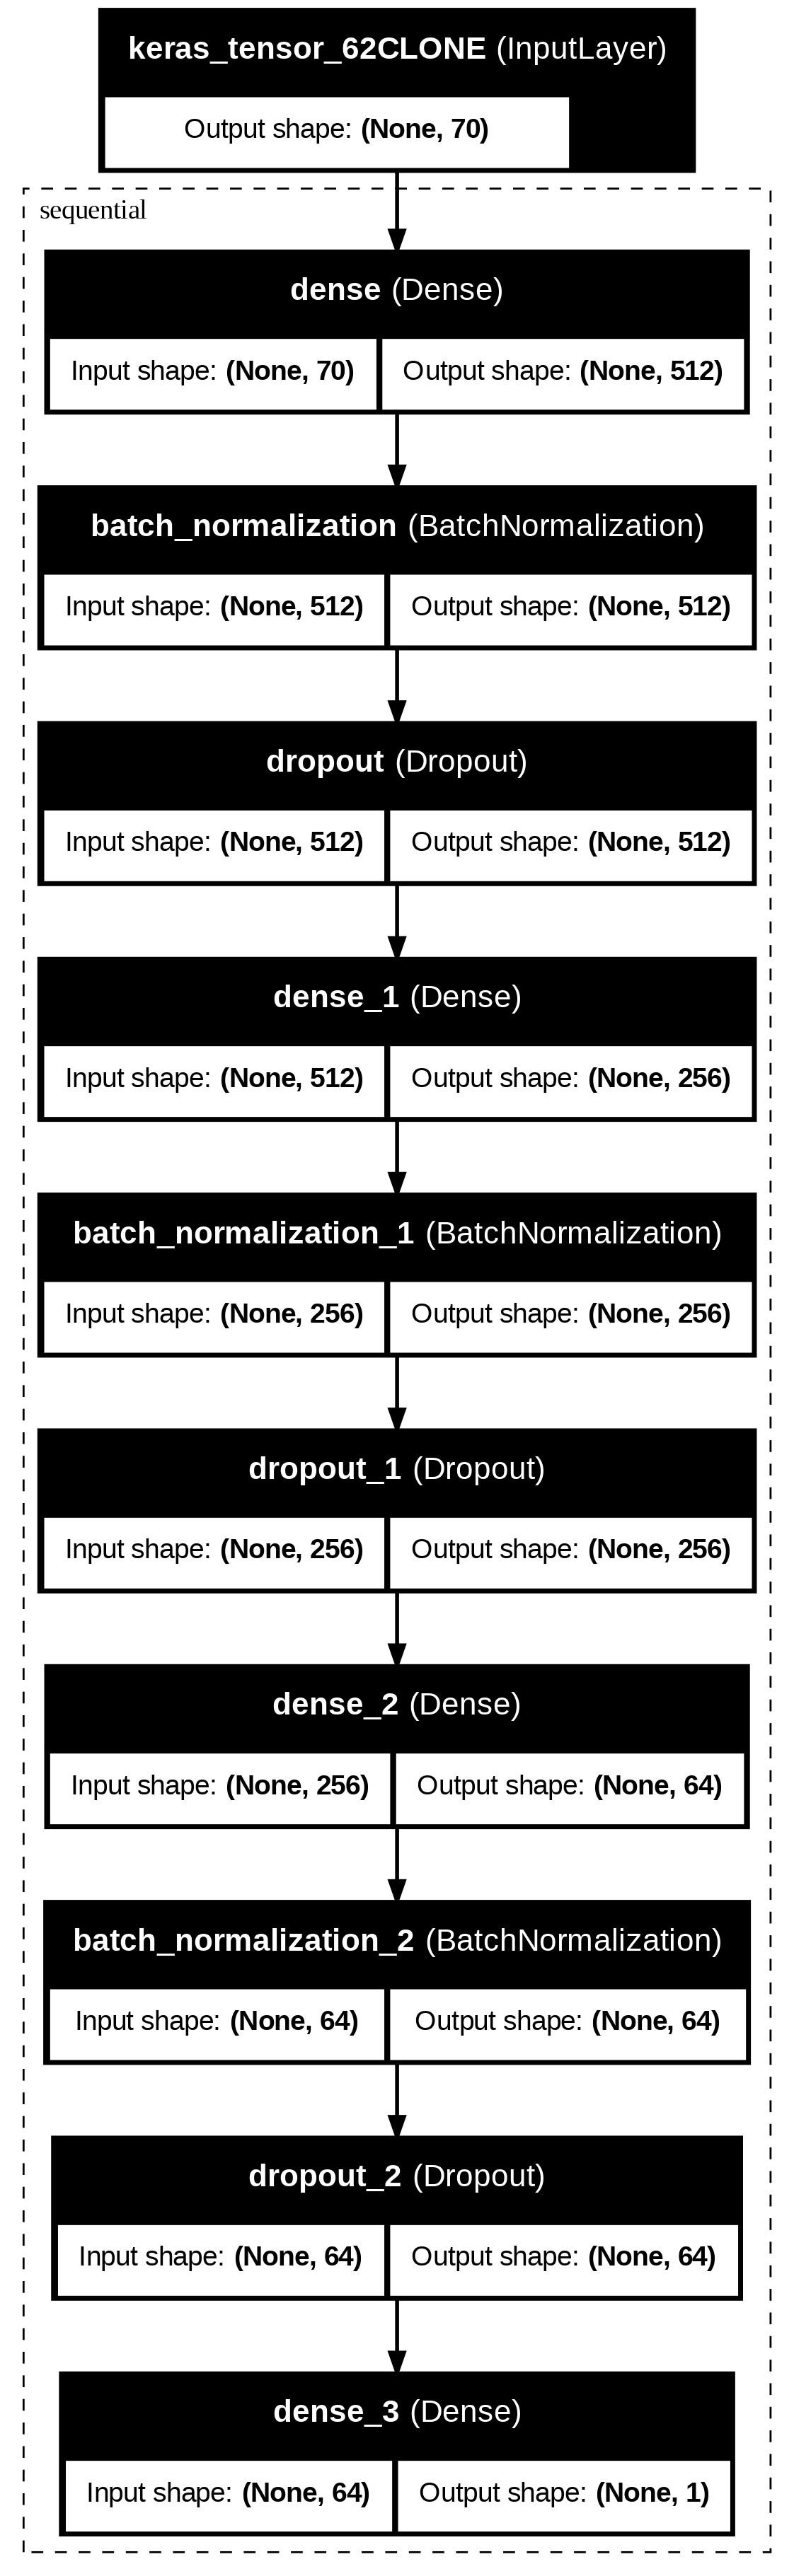

In [43]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model_fold_1.model.keras")

plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

0it [00:00, ?it/s]

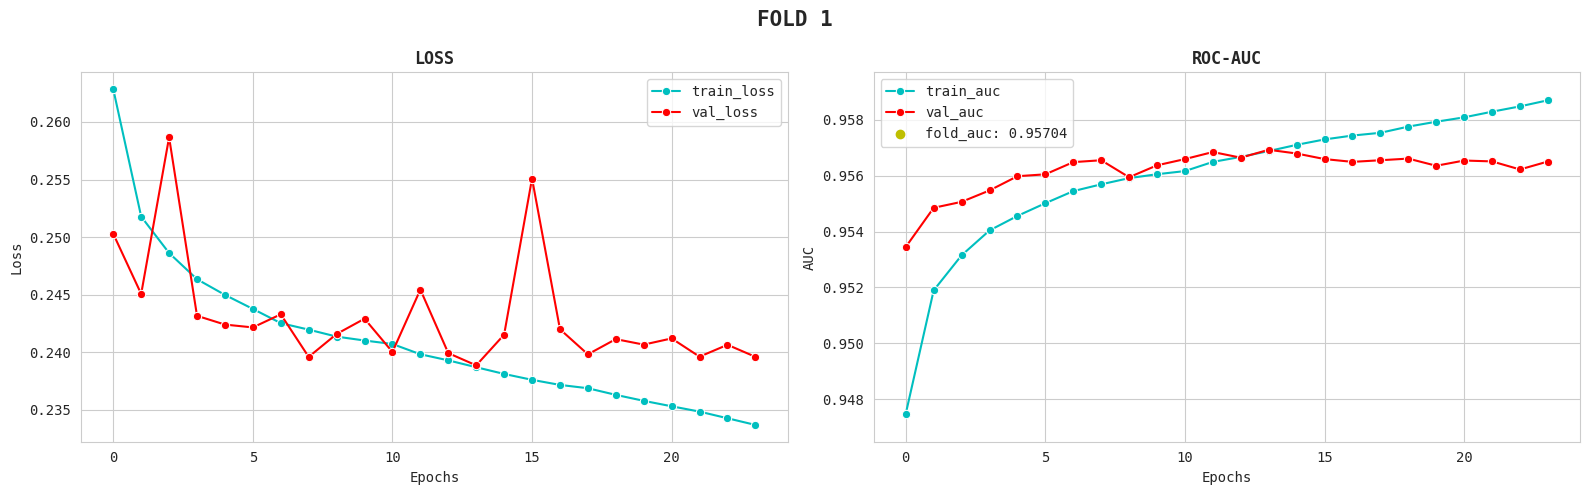

1it [00:00,  1.28it/s]

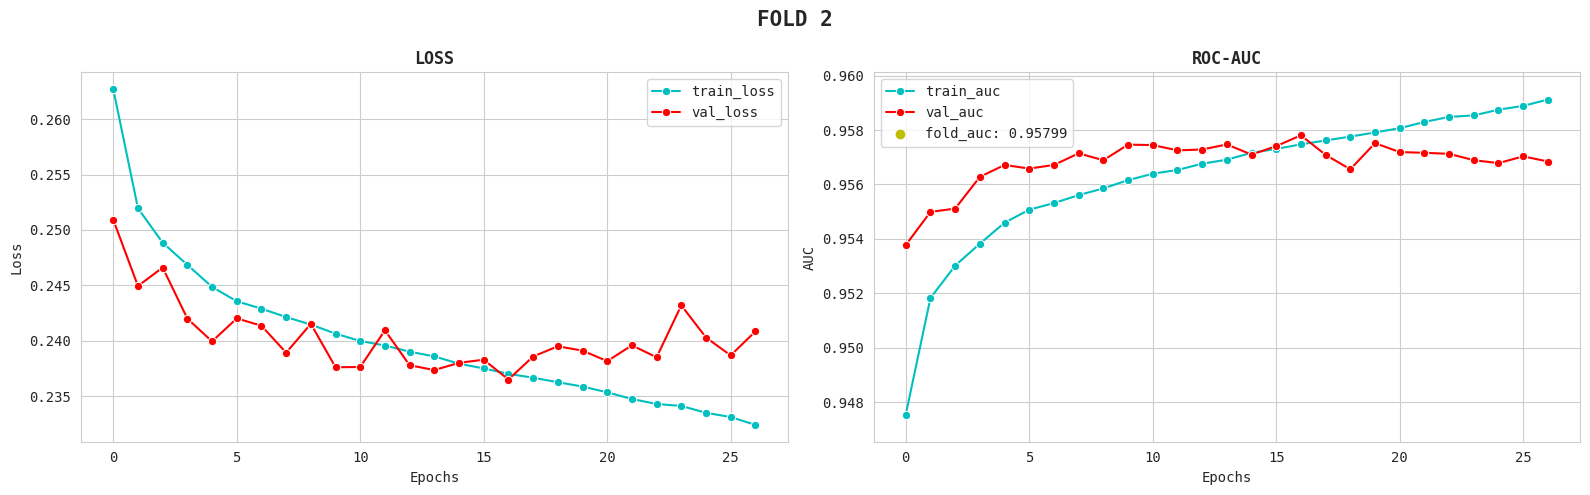

2it [00:01,  1.50it/s]

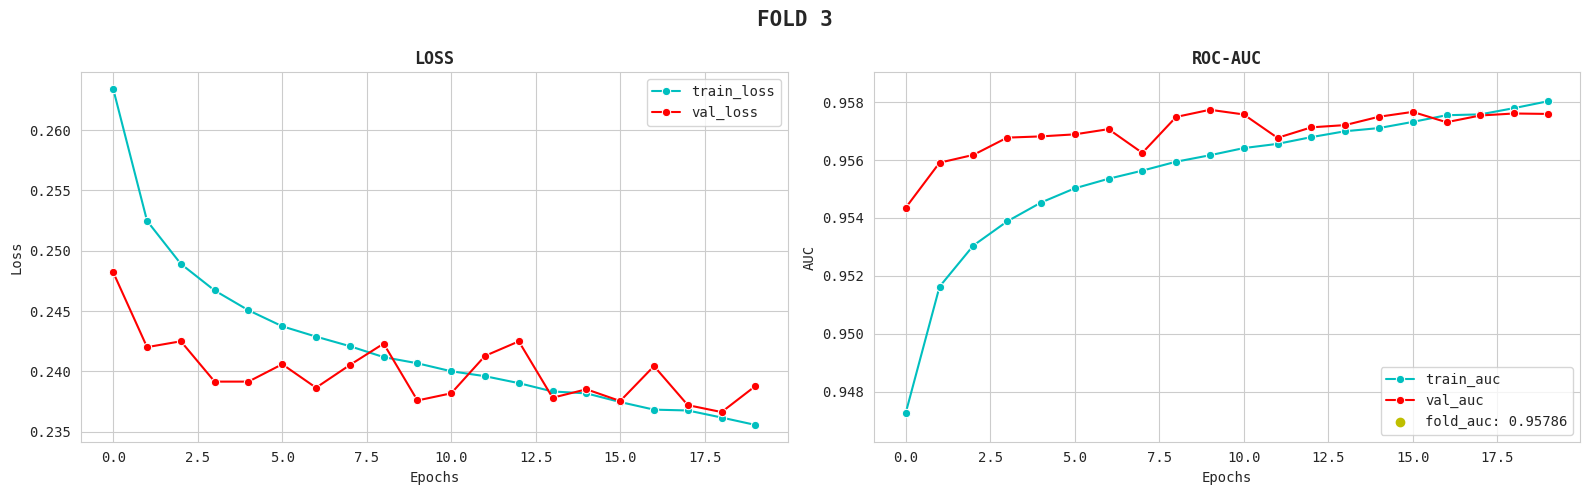

3it [00:01,  1.58it/s]

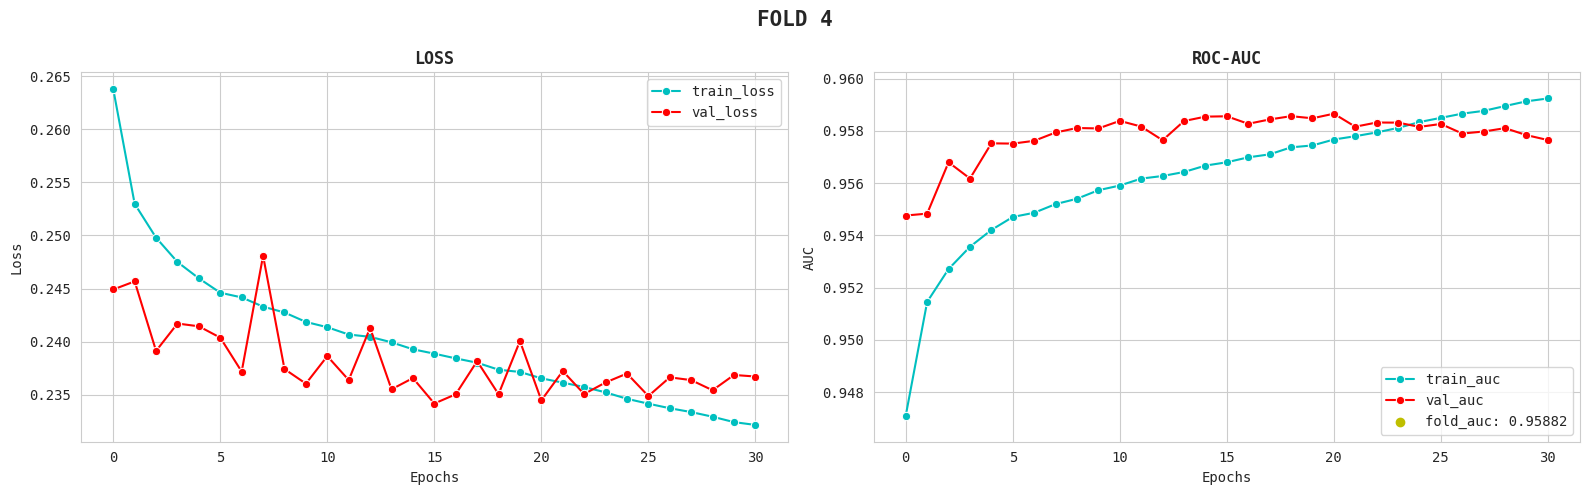

4it [00:02,  1.59it/s]

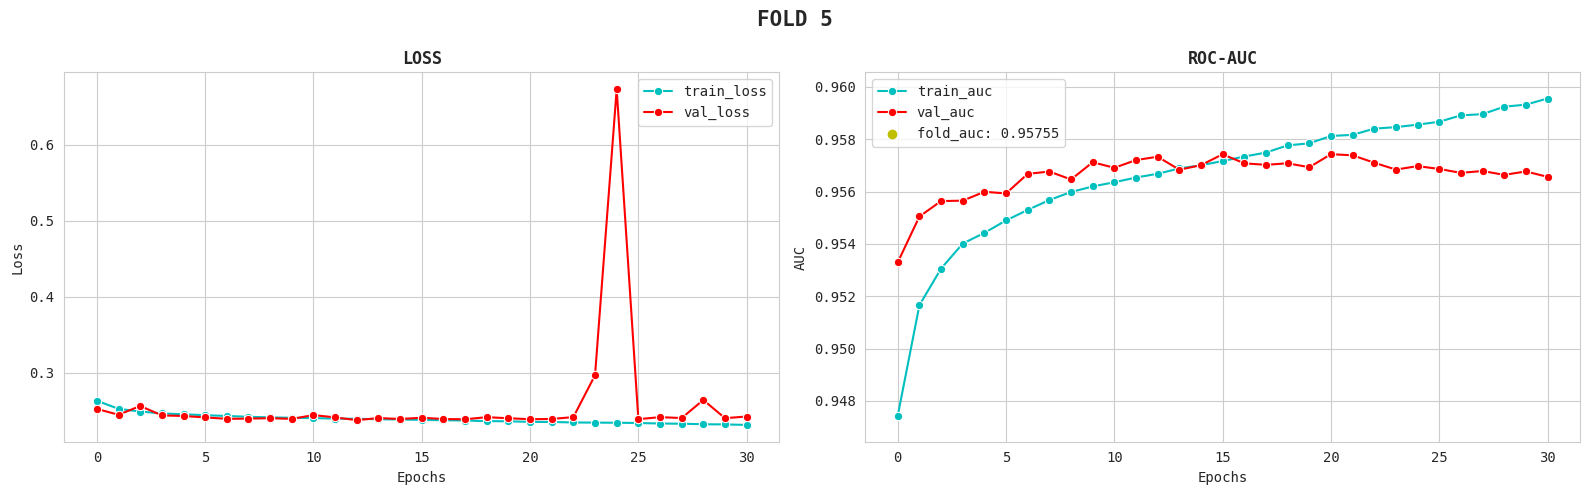

5it [00:03,  1.53it/s]

In [44]:
## -- PLOTTING RESULTS --
histories = result['history']

for i, data in tqdm(enumerate(histories)):
    loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
    auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
    plt.figure(figsize=(16, 5))
    marker = 'o'

    ## -- PLOT LOSS --
    plt.subplot(121)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
    plt.title('LOSS', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    ## -- PLOT AUC --
    plt.subplot(122)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
    plt.title('ROC-AUC', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    min_value = min(min(auc_results.train_auc)-1e-3, min(auc_results.val_auc-1e-3))
    max_value = max(max(auc_results.train_auc+1e-3), max(auc_results.val_auc+1e-3))
    plt.ylim((min_value, max_value))

    stat_ = f"fold_auc: {result['fold_score'][i]:.5f}"
    plt.scatter(x=0, y=0, label=stat_, color='y')

    plt.suptitle(f"FOLD {i+1}", fontsize=15, fontweight='semibold')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print()

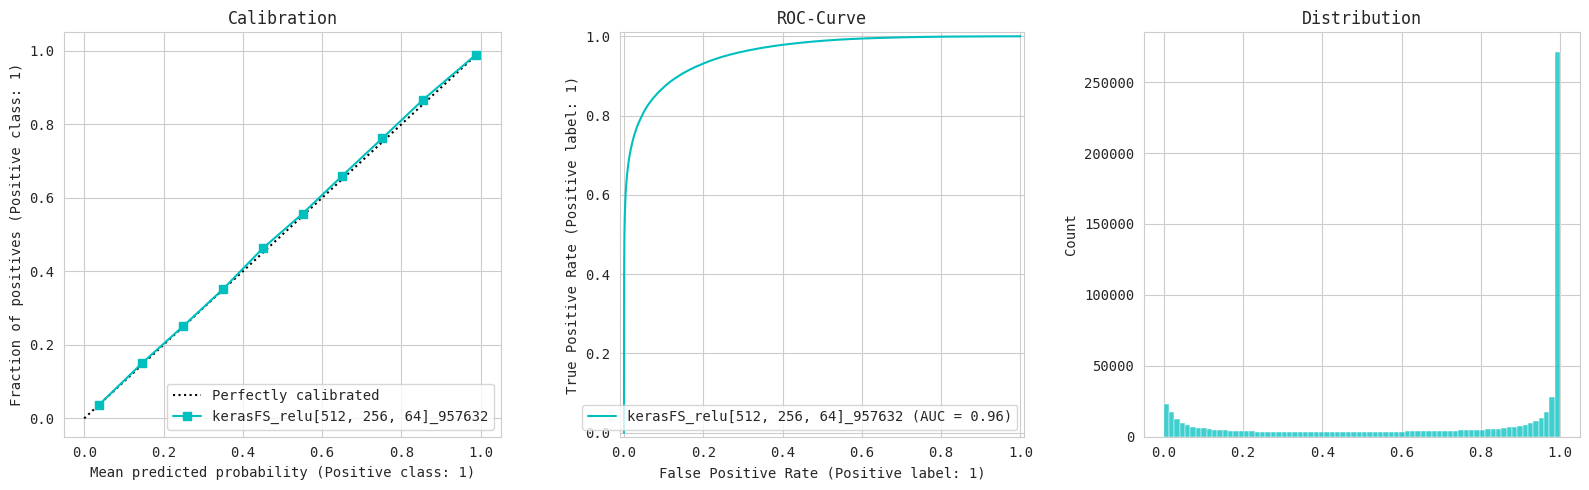

In [45]:
## -- Plot distributions --

n = f"{VERS}_{str(result['oof_score']).split('.')[1]}"

_, axs = plt.subplots(1, 3, figsize=(16, 5))
CalibrationDisplay.from_predictions(train_data[TARGET], result['oof_preds'], n_bins=10, name=n, ax=axs[0])
axs[0].set_title("Calibration")

RocCurveDisplay.from_predictions(train_data[TARGET], result['oof_preds'], name=n, ax=axs[1])
axs[1].set_title("ROC-Curve")

sns.histplot(result['oof_preds'], ax=axs[2])
axs[2].set_title("Distribution")

plt.tight_layout()
plt.show()

print()

Saved file 'submit_kerasFS_relu[512, 256, 64]_957632.csv'


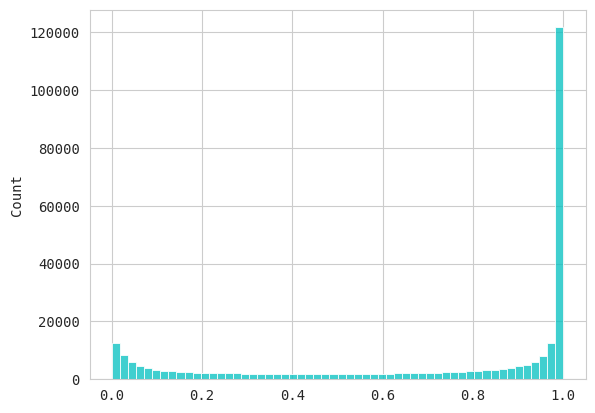

,id,addicted_label
0,691369,0.997884
1,691370,0.836982
2,691371,0.956087
3,691372,0.948604
4,691373,0.993168
...,...,...
296297,987666,1.000000
296298,987667,0.947857
296299,987668,0.159565
296300,987669,0.856473


In [46]:
## -- Save oof/test/submission files --

np.save(f"oof_{n}.npy", result["oof_preds"])
np.save(f"test_{n}.npy", result["test_preds"])

submit[TARGET] = result["test_preds"].ravel()
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Saved file 'submit_{n}.csv'")

sns.histplot(submit[TARGET].values)
plt.show()

submit